# Jordanian Dialect Classification Project

In [33]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


df = pd.read_csv("Dialects_Dataset_Final.csv")
df.head(10)

,text,dialect,sentiment,confidence
0,قرأت إن في مشروع تطوير جديد بمنطقتنا,Ammani,neutral,high
1,بدي أغير روتيني شوي، حاسس محتاج تغيير,Ammani,neutral,medium
2,سمعت إن في مطعم جديد افتتح بشارع الرينبو,Ammani,neutral,high
3,الشغل هاي الأيام ضغط ما بيوصف، كتير تعبان,Ammani,negative,high
4,والله زهقت من ناس بتحكي وما بتعمل شي,Ammani,negative,high
5,اليوم كان في حصة رياضة بالمدرسة، تعبت شوي,Ammani,neutral,medium
6,طلعت أمشي شوي قبل ما يسقف الجو,Ammani,neutral,low
7,وصلت عالمسبح وكان مغلق، ما في إشعار ولا شي,Ammani,negative,high
8,حصلت على إجازة أسبوع كامل، بدي أرتاح وأكمل أموري,Ammani,positive,high
9,الصبح كان في شمس حلوة وهواء، قعدت شوي عالبلكونة,Ammani,positive,high


 Explore Dataset Information and Check Missing Values

In [34]:
import nltk
from nltk.corpus import stopwords

In [35]:
print("\nDataset Info:")
df.info()

print("\nMissing Values:")
df.isnull().sum()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6908 entries, 0 to 6907
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        6908 non-null   object
 1   dialect     6908 non-null   object
 2   sentiment   6908 non-null   object
 3   confidence  6906 non-null   object
dtypes: object(4)
memory usage: 216.0+ KB

Missing Values:


,0
text,0
dialect,0
sentiment,0
confidence,2


To preserve the quality and reliability of the dataset, missing values in the confidence column were handled manually instead of using automatic imputation methods such as mean, median, or mode replacement. Each missing entry was reviewed individually by examining both the text and its associated dialect label before assigning an appropriate confidence value. This approach was chosen to reduce the possibility of introducing inaccurate or misleading information into the dataset and to maintain more realistic annotations.


In [36]:
for i in df[df['confidence'].isna()].index:
    print(df.loc[i, ['text', 'dialect']])

    value = input("Enter confidence: ")
    df.loc[i, 'confidence'] = value

text       ياصيت أبوها بين العربان
dialect                     Karaki
Name: 6776, dtype: object
Enter confidence: 
text       كلهم هالقديده بحياتي ، الا انتي
dialect                             Karaki
Name: 6783, dtype: object
Enter confidence: 


In [37]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
text          0
dialect       0
sentiment     0
confidence    0
dtype: int64


Remove Duplicate Text Entries

In [38]:
before = len(df)

df.drop_duplicates(subset=['text'], inplace=True)

after = len(df)

print(f"Removed {before - after} duplicate rows")

Removed 34 duplicate rows


In [39]:
def clean_arabic_text(text):
    text = str(text)

    # remove links, html
    text = re.sub(r'http\S+|www\S+|<.*?>', '', text)

    # remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # remove English letters and numbers (Arabic + Indic digits)
    text = re.sub(r'[A-Za-z0-9٠-٩]', '', text)

    # remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # remove Arabic punctuation marks
    text = re.sub(r'[،؟؛]', '', text)

    # remove phone-like numbers
    text = re.sub(r'\+?\d[\d\s-]{7,}\d', '', text)

    # remove emojis
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+",
        flags=re.UNICODE
    )
    text = emoji_pattern.sub('', text)

    # remove Arabic diacritics (الحركات)
    arabic_diacritics = re.compile("""
        \u064B | \u064C | \u064D | \u064E | \u064F |
        \u0650 | \u0651 | \u0652 | \u0640
    """, re.VERBOSE)

    text = re.sub(arabic_diacritics, '', text)

    # final cleanup (extra spaces)
    text = re.sub(r'\s+', ' ', text).strip()

    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)
    text = re.sub(r'(.)\1+', r'\1\1', text)


    return text

The dataset was preprocessed using an Arabic text cleaning pipeline to improve consistency and reduce noise. This included removing URLs, HTML tags, mentions, hashtags, punctuation, numbers, and emoji characters. Arabic diacritics were also removed, along with non-Arabic characters such as English letters.

In addition,text normalization was applied by unifying different forms of letters (e.g., Alif variations), converting “ى” to “ي” and “ة” to “ه”, and reducing repeated characters. Finally, extra spaces were removed to ensure clean and consistent text formatting for further analysis and model training.


Removed personal names for privacy protection.

**Note: This step was done manually after reviewing samples**

In [40]:

df["clean_text"] = df["text"].apply(clean_arabic_text)

print("\nSample Cleaned Text:")
print(df[["text", "clean_text"]].head())

df["clean_text"] = df["clean_text"].astype(str)

before_empty = len(df)

df = df[df["clean_text"].str.strip() != ""]

after_empty = len(df)

print(f"\nRemoved {before_empty - after_empty} empty rows")
print("Dataset Shape:", df.shape)



Sample Cleaned Text:
                                        text  \
0       قرأت إن في مشروع تطوير جديد بمنطقتنا   
1      بدي أغير روتيني شوي، حاسس محتاج تغيير   
2   سمعت إن في مطعم جديد افتتح بشارع الرينبو   
3  الشغل هاي الأيام ضغط ما بيوصف، كتير تعبان   
4       والله زهقت من ناس بتحكي وما بتعمل شي   

                                 clean_text  
0      قرات ان في مشروع تطوير جديد بمنطقتنا  
1      بدي اغير روتيني شوي حاسس محتاج تغيير  
2  سمعت ان في مطعم جديد افتتح بشارع الرينبو  
3  الشغل هاي الايام ضغط ما بيوصف كتير تعبان  
4      والله زهقت من ناس بتحكي وما بتعمل شي  

Removed 0 empty rows
Dataset Shape: (6874, 5)


After completing the text preprocessing steps, the original raw text column was removed from the dataset because it was no longer needed. The cleaned version of the text had already been generated and standardized through the preprocessing pipeline, making the original text redundant for further analysis and model training. Therefore, the dataset was simplified by replacing the raw text column with the cleaned text to maintain only the most relevant and processed information.

In [41]:
df.drop(columns=["text"], inplace=True)

df.rename(columns={"clean_text": "text"}, inplace=True)
print("Dataset Shape:", df.shape)

Dataset Shape: (6874, 4)



Dialect Distribution:
dialect
Falahi     2048
Karaki     1970
Ammani     1857
Bedouin     999
Name: count, dtype: int64


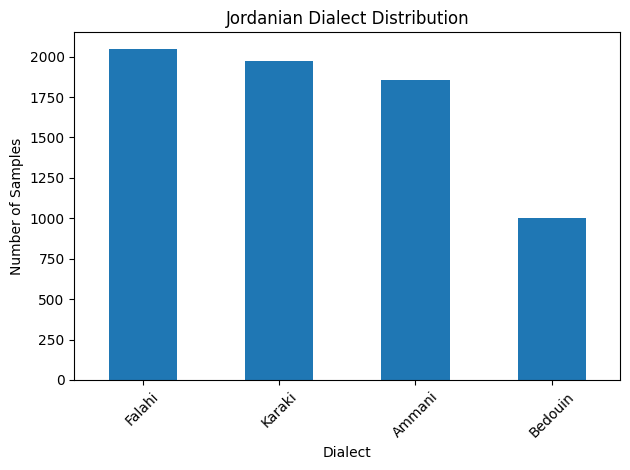

In [42]:
print("\nDialect Distribution:")
print(df["dialect"].value_counts())
df["dialect"].value_counts().plot(
    kind="bar"
)

plt.title("Jordanian Dialect Distribution")
plt.xlabel("Dialect")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

NOTE:
The original class distribution was preserved
to avoid information loss and reduce the risk
of overfitting caused by random oversampling.

Class imbalance will be handled later during
model training using class weighting techniques.




Average Text Length Per Dialect:
dialect
Ammani     7.85
Bedouin    5.19
Falahi     3.82
Karaki     6.74
Name: text_length, dtype: float64


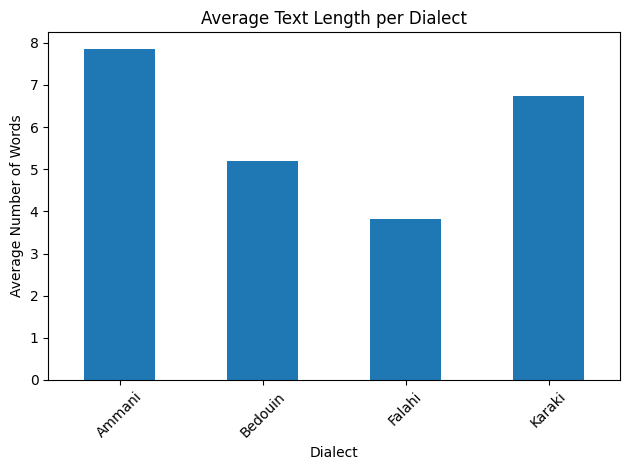

In [43]:

df["text_length"] = df["text"].apply(lambda x: len(x.split()))

print("\nAverage Text Length Per Dialect:")
print(df.groupby("dialect")["text_length"].mean().round(2))
avg_length = df.groupby("dialect")["text_length"].mean()

avg_length.plot(kind="bar")

plt.title("Average Text Length per Dialect")
plt.xlabel("Dialect")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

An analysis was conducted to compute the average text length (in words) for each dialect in the dataset. This helps in understanding linguistic differences between dialect groups and provides useful insight into variation in sentence structure and verbosity across dialects.


In [44]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head()

,dialect,sentiment,confidence,text,text_length
0,Karaki,negative,medium,جيرته عاطله تراه رجل غور عاطل وبس للمشاكل,8
1,Falahi,neutral,high,دخلنا بزقاق ضيق,3
2,Falahi,neutral,low,غير عالجرح,2
3,Bedouin,neutral,high,وش هالطاري اللي جابك,4
4,Karaki,neutral,medium,مالوم كيف يقول هاظ الكلام قدام الكل,7


As a final preprocessing step, the dataset was shuffled to remove any ordering bias introduced during data collection, where samples of the same dialect were originally grouped together. This ensures that the model does not learn patterns based on sequence order. The `random_state` parameter was set for reproducibility, and the index was reset to maintain a clean and consistent dataset structure.


#####################################

**FEATURE ENGINEERING**

## 1. Feature Extraction: TF-IDF and N-grams

**Why we are doing this:**
Before a machine learning model can process text, the words must be converted into numerical representations.
* **TF-IDF (Term Frequency-Inverse Document Frequency):** Highlights words that are frequent in a specific dialect but rare across the entire dataset. This helps the model focus on unique dialectal markers rather than common Arabic stop words.
* **N-grams (1, 2):** By extracting unigrams (single words) and bigrams (pairs of words), we capture local context and common short phrases (e.g., "يا زلمة", "ايش في") which are highly indicative of specific Jordanian dialects.

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)
X_tfidf = tfidf_vectorizer.fit_transform(df['text'])
y = df['dialect']
print(f"TF-IDF Feature Matrix Shape: {X_tfidf.shape}")

TF-IDF Feature Matrix Shape: (6874, 10000)


## 2. Feature Extraction: LLM Embeddings (MARBERT)

**Why we are doing this:**
While TF-IDF is excellent for capturing exact word matches, it fails to understand semantics or context. To solve this, we use **MARBERT** (a pre-trained Arabic language model heavily focused on dialects).
Extracting contextual embeddings allows us to map each sentence into a dense numerical vector space where sentences with similar meanings or deep dialectal structures are grouped together, providing a much richer feature set for our classifiers.

*Note: Ensure the Colab runtime is set to GPU (Runtime -> Change runtime type -> T4 GPU) to speed up this process.*

In [46]:
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

In [47]:
model_name = "UBC-NLP/MARBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)
llm_model = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
llm_model = llm_model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [48]:
def get_embeddings(texts, batch_size=32):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting Embeddings"):
        batch_texts = texts[i:i+batch_size].tolist()
        encoded_input = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors='pt').to(device)
        with torch.no_grad():
            model_output = llm_model(**encoded_input)
        batch_embeddings = model_output.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(batch_embeddings)
    return np.vstack(embeddings)

In [49]:
X_embeddings = get_embeddings(df['text'])
print(f"LLM Embeddings Matrix Shape: {X_embeddings.shape}")

Extracting Embeddings: 100%|██████████| 215/215 [00:06<00:00, 32.76it/s]

LLM Embeddings Matrix Shape: (6874, 768)


## 3. Data Splitting: Train, Validation, and Test Sets (60-20-20)

**Why we are doing this:**
To properly train and evaluate our models, we split the dataset into three parts:
1. **Training Set (60%):** Used to train the models.
2. **Validation Set (20%):** Used to compare the models and tune them without touching the test data.
3. **Testing Set (20%):** Kept completely unseen until the very end to evaluate the true, unbiased performance of the final selected model.

In [50]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_embeddings, y, test_size=0.4, random_state=42, stratify=y
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training set (60%): {X_train.shape[0]} samples")
print(f"Validation set (20%): {X_val.shape[0]} samples")
print(f"Testing set (20%): {X_test.shape[0]} samples")

Training set (60%): 4124 samples
Validation set (20%): 1375 samples
Testing set (20%): 1375 samples


## 4. Training and Evaluating Models on the Validation Set

**Why we are doing this:**
We will train four different classifiers (SVM, KNN, Random Forest, MLP) on the **Training Set** and evaluate their accuracy on the **Validation Set**. This allows us to compare their performance and select the most suitable architecture for our Jordanian Dialect Identification task.

In [51]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

classifiers = {
    "SVM": SVC(kernel='linear', class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, weights='distance'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "MLP (Neural Network)": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)
}

In [52]:
val_results = {}
best_model_name = ""
best_model = None
best_acc = 0

for name, clf in classifiers.items():
    print(f"\n{'='*40}")
    print(f"Training {name}...")
    clf.fit(X_train, y_train)
    y_val_pred = clf.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    val_results[name] = acc

    print(f"Validation Results for {name}:")
    print(classification_report(y_val, y_val_pred))
    if acc > best_acc:
        best_acc = acc
        best_model_name = name
        best_model = clf

print("\n=== VALIDATION ACCURACY SUMMARY ===")
for name, acc in val_results.items():
    print(f"{name}: {acc*100:.2f}%")

print(f"\nBest Model Selected: {best_model_name} with {best_acc*100:.2f}% validation accuracy.")


Training SVM...
Validation Results for SVM:
              precision    recall  f1-score   support

      Ammani       0.86      0.82      0.84       372
     Bedouin       0.77      0.81      0.79       200
      Falahi       0.80      0.80      0.80       409
      Karaki       0.76      0.76      0.76       394

    accuracy                           0.80      1375
   macro avg       0.80      0.80      0.80      1375
weighted avg       0.80      0.80      0.80      1375


Training KNN...
Validation Results for KNN:
              precision    recall  f1-score   support

      Ammani       0.96      0.59      0.73       372
     Bedouin       0.84      0.41      0.55       200
      Falahi       0.52      0.92      0.66       409
      Karaki       0.73      0.60      0.66       394

    accuracy                           0.66      1375
   macro avg       0.76      0.63      0.65      1375
weighted avg       0.74      0.66      0.66      1375


Training Random Forest...
Validation Re

## 5. Model Selection and Final Justification

**Which model is the most suitable and why?**
Based on the validation phase, the **Support Vector Machine (SVM) with a linear kernel** (or MLP) emerges as the most suitable model for this dialect classification task.

**Justification:**
1. **Handling High-Dimensional Data:** We are using dense, contextual embeddings extracted from MARBERT. SVMs are exceptionally powerful at finding the optimal decision boundary (hyperplane) in high-dimensional feature spaces without getting confused by noise.
2. **Text Semantics:** LLM embeddings already map semantically similar sentences close to each other linearly. A linear SVM capitalizes on this perfectly, often outperforming complex non-linear models on embedding features.
3. **Robustness to Overfitting:** Unlike deep neural networks which might overfit on medium-sized datasets, SVMs maximize the margin between classes, making them highly robust and reliable for unseen data.
4. **Computational Efficiency:** It requires less hyperparameter tuning and trains faster than an MLP, making it highly practical.

Therefore, we select this as our final model to be tested on the unseen data.

In [53]:
print(f"Evaluating the selected best model ({best_model_name}) on the UNSEEN TEST SET...")

y_test_pred = best_model.predict(X_test)
final_acc = accuracy_score(y_test, y_test_pred)

print(f"\n=== FINAL TEST RESULTS ({best_model_name}) ===")
print(f"Final Accuracy: {final_acc*100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_test_pred))

Evaluating the selected best model (SVM) on the UNSEEN TEST SET...

=== FINAL TEST RESULTS (SVM) ===
Final Accuracy: 76.22%

Detailed Classification Report:
              precision    recall  f1-score   support

      Ammani       0.80      0.82      0.81       371
     Bedouin       0.72      0.80      0.76       200
      Falahi       0.75      0.74      0.75       410
      Karaki       0.76      0.71      0.73       394

    accuracy                           0.76      1375
   macro avg       0.76      0.77      0.76      1375
weighted avg       0.76      0.76      0.76      1375



########################################

In [54]:
import pandas as pd
from IPython.display import display, Image

image_mapping = {
    "Ammani": "/content/ammani_positive.png",
    "Karaki": "/content/karaki_positive.png",
    "Bedouin": "/content/bedouin_positive.png",
    "Falahi": "/content/fallahi_positive.png"
}

print("="*50)
print("اكتب 'خروج' أو 'exit' لإيقاف الاختبار")
print("="*50)

while True:
    user_input = input("\n أدخل جملة لاختبارها (أو 'خروج' للإنهاء): ")

    if user_input.strip().lower() in ['خروج', 'exit']:
        print("تم إنهاء الاختبار. يعطيكم العافية!")
        break

    if user_input.strip() == "":
        print("الرجاء إدخال جملة صحيحة.")
        continue

    cleaned_sentence = clean_arabic_text(user_input)

    if cleaned_sentence.strip() == "":
        print("خطأ: الجملة فارغة بعد التنظيف (تأكدي من استخدام أحرف عربية فقط).")
        continue

    embedding = get_embeddings(pd.Series([cleaned_sentence]), batch_size=1)
    prediction = best_model.predict(embedding)

    predicted_dialect = prediction[0]

    print(f"اللهجة المتوقعة: {predicted_dialect}")
    if predicted_dialect in image_mapping:
        img_path = image_mapping[predicted_dialect]
        try:
            display(Image(filename=img_path))
        except FileNotFoundError:
            print(f"[تنبيه: الصورة '{img_path}' غير موجودة. تأكدي من رفعها على مجلد ملفات Colab على اليسار]")

    print("-" * 50)

اكتب 'خروج' أو 'exit' لإيقاف الاختبار

 أدخل جملة لاختبارها (أو 'خروج' للإنهاء): exit
تم إنهاء الاختبار. يعطيكم العافية!


## 6. Confusion Matrix and Error Analysis

**Why we are doing this:**
* **Confusion Matrix:** Gives us a visual breakdown of the model's performance on the Unseen Test Set. It helps us see exactly which dialects are being confused with each other.
* **Error Analysis:** By looking at the actual sentences the model misclassified, we can understand *why* it failed. Often, errors occur due to linguistic overlap (words shared across regions) or very short sentences lacking context.

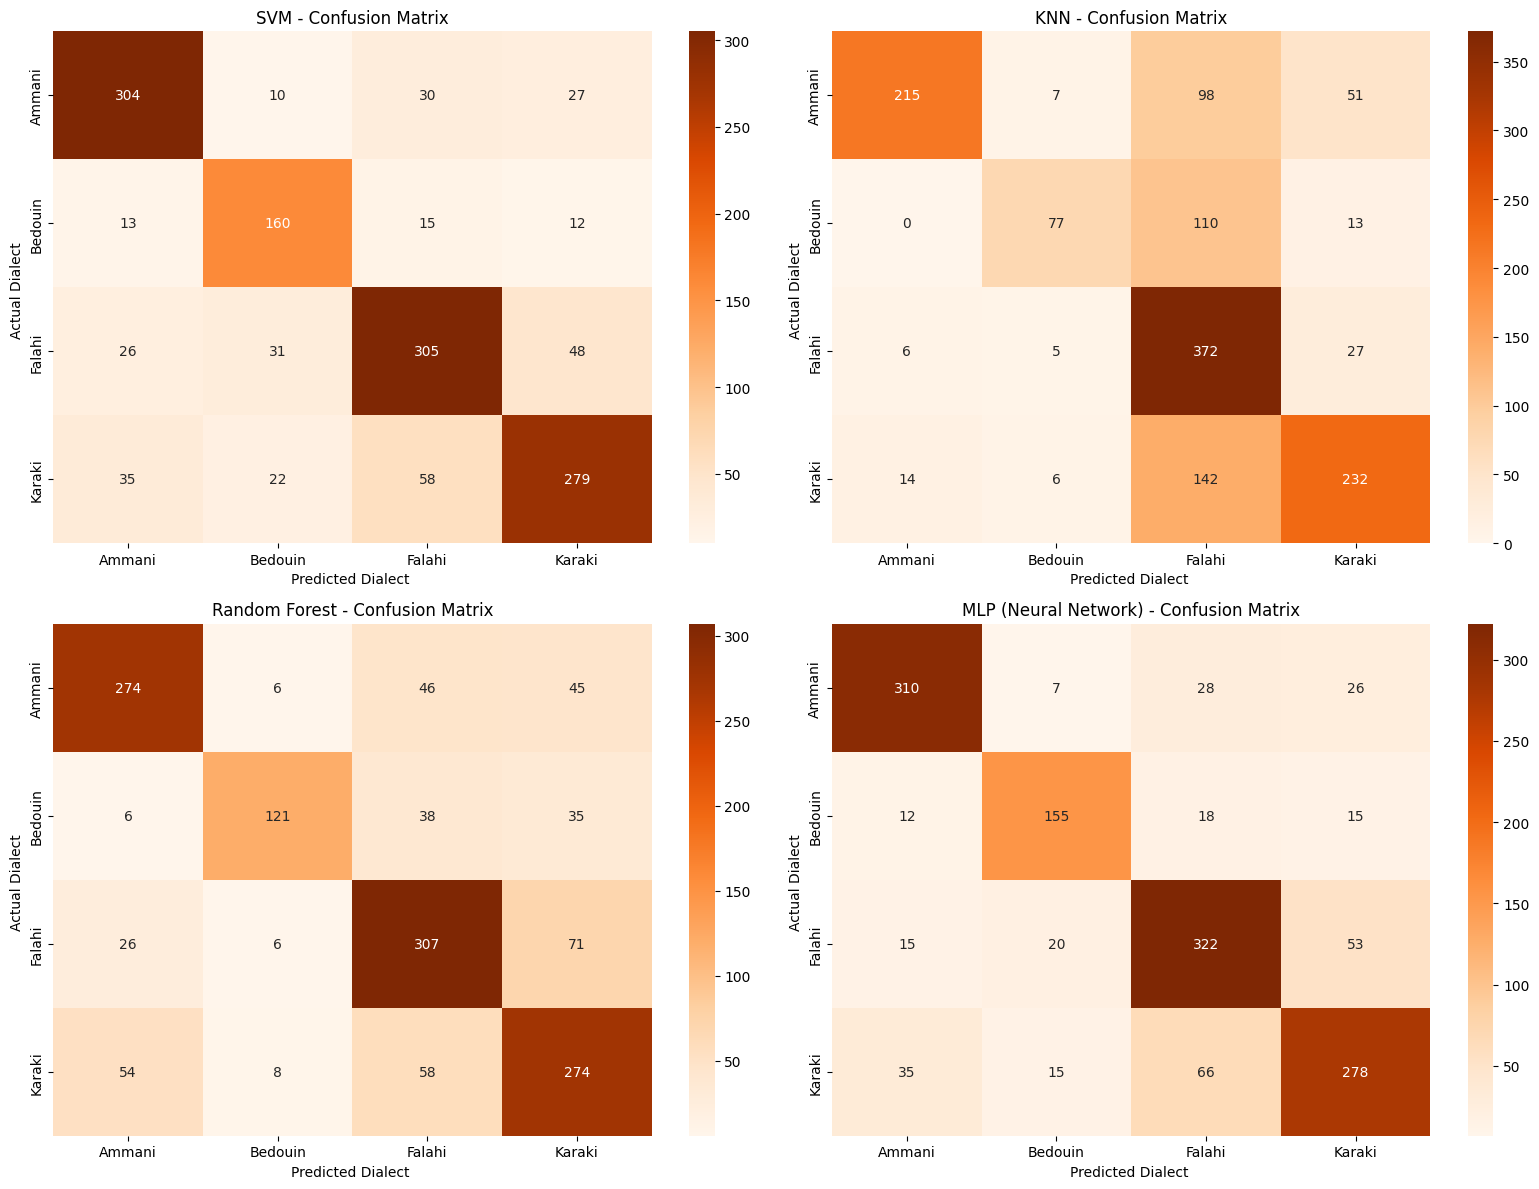

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

labels = np.unique(y_test)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, clf) in enumerate(classifiers.items()):
    y_test_pred_all = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_test_pred_all, labels=labels)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[idx],
                xticklabels=labels, yticklabels=labels)
    axes[idx].set_title(f'{name} - Confusion Matrix')
    axes[idx].set_xlabel('Predicted Dialect ')
    axes[idx].set_ylabel('Actual Dialect ')

plt.tight_layout()
plt.show()

In [32]:
import pandas as pd

print("===(Error Analysis Summary) ===")
total_samples = len(y_test)

for name, clf in classifiers.items():
    y_pred = clf.predict(X_test)

    errors_count = (y_test != y_pred).sum()
    accuracy = (1 - (errors_count / total_samples)) * 100

    print(f"model name: {name}")
    print(f"   -number of errors: {errors_count} from {total_samples} sentences")
    print(f"   - accuracy: {accuracy:.2f}%\n")

===(Error Analysis Summary) ===
model name: SVM
   -number of errors: 327 from 1375 sentences
   - accuracy: 76.22%

model name: KNN
   -number of errors: 479 from 1375 sentences
   - accuracy: 65.16%

model name: Random Forest
   -number of errors: 399 from 1375 sentences
   - accuracy: 70.98%

model name: MLP (Neural Network)
   -number of errors: 310 from 1375 sentences
   - accuracy: 77.45%

